In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [2]:
(x_test,y_test),(x_train,y_train)=keras.datasets.mnist.load_data()

In [3]:
x_test.shape

(60000, 28, 28)

In [4]:
x_test[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

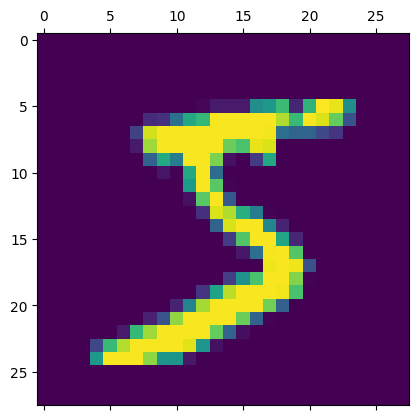

In [5]:
plt.matshow(x_test[0])
plt.show()

In [6]:
y_test[0:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [7]:
#normalize
x_test=x_test/255
x_train=x_train/255

In [8]:
# reshape
x_trainr=x_train.reshape(-1,28,28,1)
x_testr=x_test.reshape(-1,28,28,1)

In [9]:
#model
model=keras.Sequential()

#1st layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

#2nd layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

#3rd layer
model.add(Conv2D(128,(3,3),activation='relu'))

#flatten
model.add(Flatten())

#fully connected layer
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

c:\project_intership\project 5\demo\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.fit(x_trainr,y_train,epochs=5)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8888 - loss: 0.3686
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9724 - loss: 0.0852
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9839 - loss: 0.0494
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9892 - loss: 0.0314
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9898 - loss: 0.0279


In [11]:
model.evaluate(x_testr,y_test)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9729 - loss: 0.1004


[0.10041279345750809, 0.9728833436965942]

In [12]:
y_pred=model.predict(x_testr)
y_pred[5]

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step


array([4.8017802e-07, 2.7083098e-08, 9.9997950e-01, 5.3655745e-06,
       2.9636038e-10, 1.5471759e-10, 9.4122479e-09, 8.3874127e-08,
       1.4544640e-05, 2.8013304e-08], dtype=float32)

In [13]:
y_pred_labels=np.argmax(y_pred,axis=1)
y_pred_labels[0:6]

array([5, 0, 4, 1, 9, 2])

In [14]:
import pickle
with open('model.pkl','wb') as f:
    pickle.dump(model,f)